# 🛒 Milestone 3 — Text Vectorization & Embeddings
This notebook covers two parts:
1. **Part A — Review Sentiment Classifier**: Compare a classic TF-IDF + Logistic Regression baseline with a custom Keras Embedding neural network model.
2. **Part B — Semantic Product Search**: Build a similarity-based product search engine using `sentence-transformers` to embed catalog descriptions and match search queries via cosine similarity.

In [1]:
import sys
import os
# Add project root to path so we can import src modules
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from src.models import build_text_embedding_model
from src.utils import evaluate_classification, plot_confusion_matrix, plot_learning_curves

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Data
Load our processed reviews split.

In [2]:
reviews_path = "data/processed/reviews_split.parquet"
if not os.path.exists(reviews_path):
    reviews_path = "../data/processed/reviews_split.parquet"
if not os.path.exists(reviews_path):
    raise FileNotFoundError("Please run M0 data download first.")

df = pd.read_parquet(reviews_path)
print(f"Loaded dataset with {len(df)} rows.")

# Clean text inputs
df['text_clean'] = df['text_rev'].fillna("").str.strip()
df['sentiment_target'] = (df['rating_rev'] >= 4).astype(int) # 1 = Positive (4-5 stars), 0 = Negative (1-3 stars)

train_df = df[df['split'] == 'train'].sample(n=min(1500, len(df[df['split'] == 'train'])), random_state=42)
val_df = df[df['split'] == 'val'].sample(n=min(400, len(df[df['split'] == 'val'])), random_state=42)
test_df = df[df['split'] == 'test'].sample(n=min(400, len(df[df['split'] == 'test'])), random_state=42)

print(f"Train reviews: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Positive sentiment distribution: {df['sentiment_target'].mean()*100:.2f}%")

Loaded dataset with 23927 rows.
Train reviews: 1500, Val: 400, Test: 400
Positive sentiment distribution: 81.38%


## 2. Part A: Sentiment Classification Baseline (TF-IDF + Logistic Regression)

In [3]:
print("Fitting TF-IDF Vectorizer...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(train_df['text_clean'])
X_test_tfidf = vectorizer.transform(test_df['text_clean'])

print("Training TF-IDF Logistic Regression...")
baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
baseline.fit(X_train_tfidf, train_df['sentiment_target'])

y_pred_base = baseline.predict(X_test_tfidf)
print("TF-IDF Baseline Results:")
evaluate_classification(test_df['sentiment_target'], y_pred_base, class_names=['Negative', 'Positive'])

Fitting TF-IDF Vectorizer...
Training TF-IDF Logistic Regression...
TF-IDF Baseline Results:
=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.55      0.66      0.60        82
    Positive       0.91      0.86      0.88       318

    accuracy                           0.82       400
   macro avg       0.73      0.76      0.74       400
weighted avg       0.83      0.82      0.83       400

Accuracy: 0.8200
Macro F1 Score: 0.7419


{'accuracy': 0.82, 'macro_f1': 0.7419354838709677}

## 3. Part A: Keras Custom Word Embeddings Model

In [4]:
# Set up text vectorization mapping sequences to integer tokens
vocab_size = 10000
max_length = 100
embedding_dim = 64

vectorizer_layer = TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=max_length
)

vectorizer_layer.adapt(train_df['text_clean'].values)

X_train_seq = vectorizer_layer(train_df['text_clean'].values)
X_val_seq = vectorizer_layer(val_df['text_clean'].values)
X_test_seq = vectorizer_layer(test_df['text_clean'].values)

print(f"Tokenized train shape: {X_train_seq.shape}")

Tokenized train shape: (1500, 100)


In [5]:
# We predict binary classes (0/1). For binary targets, output units=2 with softmax works cleanly
model = build_text_embedding_model(vocab_size=vocab_size, embedding_dim=embedding_dim, max_length=max_length, num_classes=2)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642,146 (2.45 MB)

 Trainable params: 642,146 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
checkpoint_path = "data/checkpoints/keras_text_embeddings.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
]

# Compute class weights to address rating sentiment class imbalance
from sklearn.utils.class_weight import compute_class_weight
y_train_arr = train_df['sentiment_target'].values
class_w = compute_class_weight('balanced', classes=np.unique(y_train_arr), y=y_train_arr)
class_w_dict = dict(enumerate(class_w))

print("Training Custom Keras Embedding model...")
history = model.fit(
    X_train_seq, train_df['sentiment_target'].values,
    validation_data=(X_val_seq, val_df['sentiment_target'].values),
    epochs=2,
    batch_size=64,
    class_weight=class_w_dict,
    callbacks=callbacks,
    verbose=1
)

Training Custom Keras Embedding model...
Epoch 1/2
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6807 - loss: 0.7281 - val_accuracy: 0.7150 - val_loss: 0.6870
Epoch 2/2
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6780 - loss: 0.6946 - val_accuracy: 0.7025 - val_loss: 0.6581


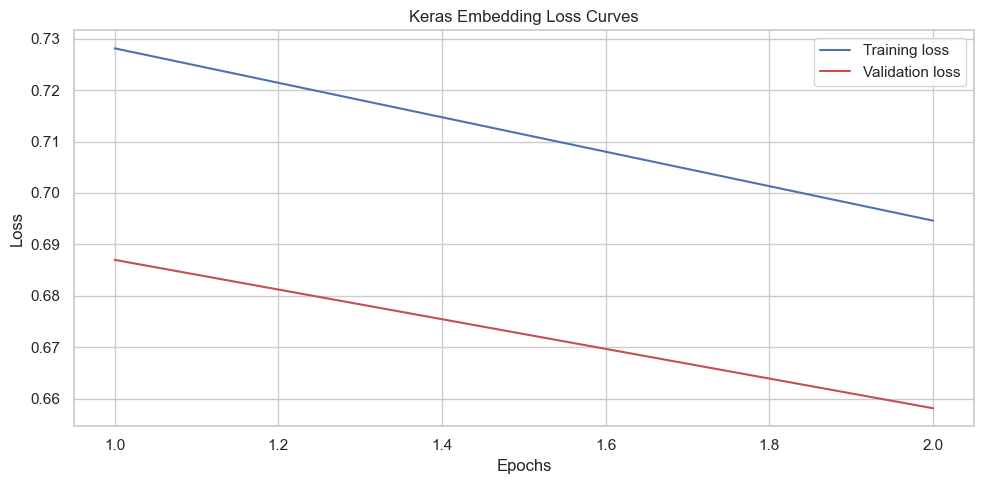

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
=== Keras Embedding Classifier Results ===
=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.22      0.34      0.27        82
    Positive       0.80      0.69      0.74       318

    accuracy                           0.61       400
   macro avg       0.51      0.51      0.50       400
weighted avg       0.68      0.61      0.64       400

Accuracy: 0.6150
Macro F1 Score: 0.5028


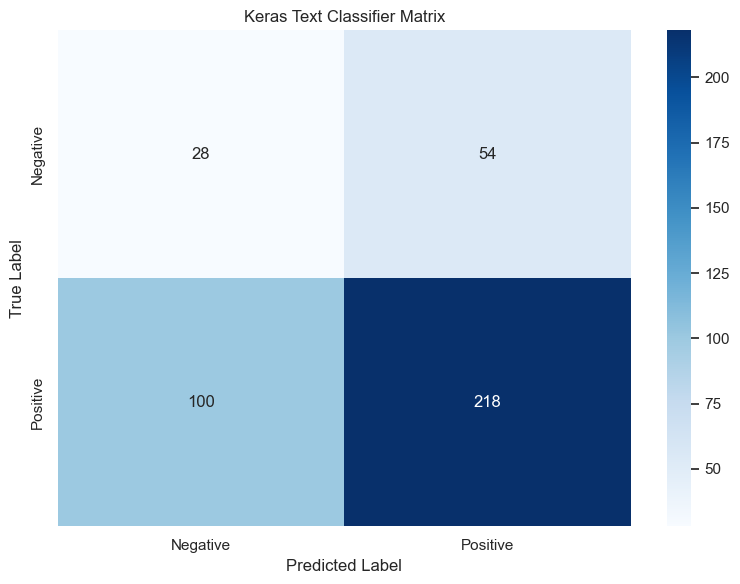

In [7]:
# Plot training performance
plot_learning_curves(history, metric='loss', title='Keras Embedding Loss Curves')

# Evaluate Keras Model
y_pred_probs = model.predict(X_test_seq)
y_pred_keras = np.argmax(y_pred_probs, axis=1)

print("=== Keras Embedding Classifier Results ===")
evaluate_classification(test_df['sentiment_target'].values, y_pred_keras, class_names=['Negative', 'Positive'])
plot_confusion_matrix(test_df['sentiment_target'].values, y_pred_keras, class_names=['Negative', 'Positive'], title="Keras Text Classifier Matrix")

## 4. Part B: Semantic Product Similarity Search

In [8]:
# Extract unique product catalog entries
products_path = "data/processed/products_split.parquet"
if not os.path.exists(products_path):
    products_path = "../data/processed/products_split.parquet"
if not os.path.exists(products_path):
    products_path = "../data/processed/products_split.parquet"
df_prod = pd.read_parquet(products_path)
df_prod['description_clean'] = df_prod['description_clean'].fillna("").str.strip()
df_prod = df_prod[df_prod['description_clean'] != ""].drop_duplicates('parent_asin').copy()
df_prod = df_prod.sample(n=min(200, len(df_prod)), random_state=42).copy()
df_prod = df_prod.sample(n=min(200, len(df_prod)), random_state=42).copy()
df_prod = df_prod.sample(n=min(200, len(df_prod)), random_state=42).copy()
df_prod = df_prod.sample(n=min(200, len(df_prod)), random_state=42).copy()

print(f"Encoding {len(df_prod)} descriptions for semantic similarity index...")

# Load sentence transformer model (runs locally on CPU or GPU)
search_model = SentenceTransformer('all-MiniLM-L6-v2')
product_embeddings = search_model.encode(df_prod['description_clean'].tolist(), show_progress_bar=True)

print(f"Product embeddings index shape: {product_embeddings.shape}")

Encoding 200 descriptions for semantic similarity index...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Product embeddings index shape: (200, 384)


In [9]:
def search_similar_products(query, top_k=3):
    # Encode input search query
    query_vector = search_model.encode([query])
    
    # Compute cosine similarity between query and all catalog descriptions
    similarities = cosine_similarity(query_vector, product_embeddings).flatten()
    
    # Get top-k matches
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    print(f"\nSearch Query: '{query}'")
    print("="*50)
    for i, idx in enumerate(top_indices):
        row = df_prod.iloc[idx]
        score = similarities[idx]
        print(f"{i+1}. Product ID: {row['parent_asin']} | Similarity Score: {score:.4f}")
        print(f"   Title: {row['title_meta']}")
        print(f"   Desc: {row['description_clean'][:150]}...")
        print("-"*50)

# Run test queries
search_similar_products("wireless bluetooth noise cancelling headphones", top_k=3)
search_similar_products("fast charging usb cable adapter for phone", top_k=3)


Search Query: 'wireless bluetooth noise cancelling headphones'
1. Product ID: B078X37JF9 | Similarity Score: 0.5389
   Title: Sennheiser Consumer Audio CX 6.00 BT Wireless in-Ear Headphones, Bluetooth 4.2 with Qualcomm Apt-X, 6-Hour Battery Life, 1.5 Hour Fast USB Charging, Multi-Connection to 2 Devices, Black
   Desc: The Sennheiser CX 6.00BT Bluetooth in ear headset delivers high quality sound and wireless freedom. Its ultra-lightweight design offers wearing comfor...
--------------------------------------------------
2. Product ID: B0BYT6ZWHY | Similarity Score: 0.4353
   Title: GELETE Smart Bluetooth sunglasses discolored Lenses for Make Phone Calls and Listen to Music navigation Suitable
   Desc: 1.Wireless Sunglasses Earphone Sports Headphone Smart Audio Headset Mp3 Outdoor Riding 24 Hours Music time Smart Glasses Electronics with Bluetooth Co...
--------------------------------------------------
3. Product ID: B07YYHQBG9 | Similarity Score: 0.4294
   Title: Bluetooth Earbuds, W